# SOCAT v2026 — exploring the data through the zarr data-passport proxy

The ICOS Zarr proxy at **https://zarr.icos-cp.eu** serves two SOCAT v2026 stores:

| store | what | shape |
|---|---|---|
| `socat.zarr` | full synthesis — every QC'd surface-ocean fCO2 observation | flat `_obs` table, 44 M obs / 8 391 cruises |
| `socat-gridded.zarr` | the 1°×1° monthly gridded product | `(time, lat, lon)` cube |

The pattern throughout is **download into a pandas DataFrame, then plot** — either
through the `/query` REST API (server-side bbox/time/QC filter → NDJSON, plus a
data-passport) or by opening a store with `xarray` and `.to_dataframe()`.

What we'll do:
1. a single cruise · 2. all cruises of one ship · 3. gridded fCO2 on a rotating globe ·
4. all North-Atlantic cruises in a 5-year window on a map ·
5. the 2000–2025 regional fCO2 trend, from the gridded product **and** from the cruises.

> **Reducing tracks for plotting.** SOCAT is far too large to draw every point.
> Cruise tracks are thinned with a **piecewise-linear (Douglas–Peucker) approximation**
> on `(lon, lat, fCO2)`: a point is kept only if it lies more than **1°** (position)
> or **4 µatm** (fCO2) off the straight segment joining its neighbours. This keeps a
> faithful path and every local fCO2 extremum while cutting the data to roughly a few
> percent of the points. The DataFrames and statistics always use the full data.

*Advanced example — notebook 13 of the [sample series](README.md). Builds on notebooks 05 (ICOS SOCAT) and 09 (gridded cube). No account needed. Committed outputs use plotly's static PNG renderer; in live Jupyter, comment the `pio.renderers` line out to get the interactive maps and the spinning globe.*

In [1]:
import json
import numpy as np
import pandas as pd
import requests
import xarray as xr
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# Static PNG output (kaleido) so the committed notebook renders on GitHub —
# comment this out in live Jupyter for interactive plotly maps + the globe.
pio.renderers.default = "png"

PROXY = "https://zarr.icos-cp.eu"
SYNTH = f"{PROXY}/socat.zarr/"
GRID  = f"{PROXY}/socat-gridded.zarr/"

# North Atlantic study region (used from section 4 on)
NA = dict(lat_min=40, lat_max=65, lon_min=-60, lon_max=-10)
MAXDRAW = 15000   # hard cap on markers drawn in any one busy map (after reduction)

def reduce_track(lon, lat, val, pos_tol=1.0, val_tol=4.0):
    # Douglas-Peucker on a cruise track in (lon, lat, value) space, with
    # SEPARATE tolerances: position (degrees) and value (uatm). A point is kept
    # if its perpendicular distance to the current segment exceeds pos_tol OR its
    # deviation from the segment's linear value-interpolation exceeds val_tol.
    # Endpoints and all local extrema are retained. Returns a boolean keep-mask.
    lon = np.asarray(lon, float); lat = np.asarray(lat, float); val = np.asarray(val, float)
    n = len(lon)
    keep = np.zeros(n, dtype=bool)
    if n == 0:
        return keep
    keep[0] = keep[-1] = True
    stack = [(0, n - 1)]
    while stack:
        i, j = stack.pop()
        if j <= i + 1:
            continue
        k = np.arange(i + 1, j)
        dx, dy = lon[j] - lon[i], lat[j] - lat[i]
        seg2 = dx * dx + dy * dy
        t = (((lon[k] - lon[i]) * dx + (lat[k] - lat[i]) * dy) / seg2) if seg2 else np.zeros(len(k))
        t = np.clip(t, 0.0, 1.0)
        pos_dev = np.hypot(lon[k] - (lon[i] + t * dx), lat[k] - (lat[i] + t * dy))
        val_dev = np.abs(val[k] - (val[i] + t * (val[j] - val[i])))
        val_dev = np.where(np.isfinite(val_dev), val_dev, 0.0)
        score = np.maximum(pos_dev / pos_tol, val_dev / val_tol)
        m = int(np.argmax(score))
        if score[m] > 1.0:
            kk = k[m]
            keep[kk] = True
            stack.append((i, kk)); stack.append((kk, j))
    return keep

def reduce_by_cruise(df, key, pos_tol=1.0, val_tol=4.0, cap=MAXDRAW):
    # Apply reduce_track per cruise (rows are already time-ordered within a
    # cruise), concatenate, and cap the total for rendering. df needs columns
    # longitude / latitude / fCO2 and a grouping column `key`.
    parts = []
    for _, gdf in df.dropna(subset=["fCO2"]).groupby(key, sort=False):
        if len(gdf) < 2:
            parts.append(gdf); continue
        keep = reduce_track(gdf.longitude.values, gdf.latitude.values, gdf.fCO2.values,
                            pos_tol, val_tol)
        parts.append(gdf[keep])
    red = pd.concat(parts, ignore_index=True) if parts else df.iloc[:0]
    return red.sample(cap, random_state=0) if len(red) > cap else red

print("stores served:", requests.get(PROXY + "/").json()["stores"])

stores served: ['icos-fluxnet.zarr', 'icos-obspack.zarr', 'icos-socat.zarr', 'socat-gridded.zarr', 'socat.zarr']


### The variable catalogue and a `/query` → DataFrame helper

In [2]:
cat = pd.DataFrame(requests.get(PROXY + "/variables").json())
display(cat[["id", "longname", "unit", "zarr_store", "query_kind", "quality_flag_variable"]]
        .sort_values("zarr_store").reset_index(drop=True))

def query_df(var_id, **params):
    # GET /query and load the streamed NDJSON into a DataFrame.
    # The proxy filters server-side by bbox / time / QC and streams one JSON
    # object per matching row; the final line is a RO-Crate *data passport*
    # documenting exactly this download. Returns (df, passport).
    q = {"id": var_id, **{k: v for k, v in params.items() if v is not None}}
    rows, passport = [], None
    with requests.get(PROXY + "/query", params=q, stream=True) as r:
        r.raise_for_status()
        for line in r.iter_lines():
            if not line:
                continue
            obj = json.loads(line)
            if "_passport" in obj:
                passport = obj["_passport"]
            else:
                rows.append(obj)
    df = pd.DataFrame(rows)
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"])
    return df, passport

,id,longname,unit,zarr_store,query_kind,quality_flag_variable
0,icos-fluxnet._combined-fluxnet_dd.CO2_F_MDS,CO2 Mole Fraction (gap-filled by Marginal Dist...,umol mol-1,icos-fluxnet.zarr,station_time,CO2_F_MDS_QC
1,icos-fluxnet._combined-fluxnet_dd.DAY_D,Day D,1,icos-fluxnet.zarr,station_time,NaN
2,icos-fluxnet._combined-fluxnet_dd.DAY_RANDUNC_N,Day Randunc N,1,icos-fluxnet.zarr,station_time,NaN
3,icos-fluxnet._combined-fluxnet_dd.EBC_CF_METHOD,Energy Balance Closure Method Flag,1,icos-fluxnet.zarr,station_time,NaN
4,icos-fluxnet._combined-fluxnet_dd.EBC_CF_N,Energy Balance Closure Correction Factor N,1,icos-fluxnet.zarr,station_time,NaN
...,...,...,...,...,...,...
517,socat._obs.southmost,southmost,degrees_north,socat.zarr,obs_table,NaN
518,socat._obs.version,version,,socat.zarr,obs_table,NaN
519,socat._obs.westmost,westmost,degrees_east,socat.zarr,obs_table,NaN
520,socat._obs.xCO2water_SST_dry,"xCO2 in water (SST, dry air)",umol mol-1,socat.zarr,obs_table,NaN


### Open both stores lazily and pull the small per-cruise metadata block

In [3]:
obs  = xr.open_zarr(SYNTH, group="_obs", consolidated=True)
grid = xr.open_zarr(GRID, consolidated=True)
print("synthesis _obs:", dict(obs.sizes))
print("gridded cube  :", dict(grid.sizes))

# The (cruise,) metadata block is tiny (8 391 rows) — load it into a DataFrame.
cruise_cols = ["cruise", "platform_name", "pis", "time_start", "time_end",
               "obs_start", "obs_count", "westmost", "eastmost", "southmost", "northmost"]
# `cruise` is a dimension coordinate, so reset_index() turns it back into a column.
cm = obs[cruise_cols].to_dataframe().reset_index()
for c in ["cruise", "platform_name", "pis", "time_start", "time_end"]:
    cm[c] = cm[c].astype(str)
cm.head()

synthesis _obs: {'obs': 44018204, 'cruise': 8391}
gridded cube  : {'time': 577, 'lat': 180, 'lon': 360}


,cruise,platform_name,pis,time_start,time_end,obs_start,obs_count,westmost,eastmost,southmost,northmost
0,069920180814,Malizia,"Landschützer, P.",2018-08-14,2018-08-16,0.0,9422.0,-4.850000,-2.82,47.740002,49.830002
1,069920180921,Malizia,"Landschützer, P.",2018-09-21,2018-09-22,9422.0,5192.0,-6.300000,-3.50,46.990002,47.740002
2,069920181126,Malizia,"Landschützer, P.",2018-11-26,2018-11-28,14614.0,16639.0,-61.320000,-56.77,16.040001,22.540001
3,069920190503,Malizia,"Landschützer, P.",2019-05-03,2019-05-04,31253.0,3685.0,-4.950000,-3.94,47.639999,48.150002
4,069920190509,Malizia,"Landschützer, P.",2019-05-09,2019-05-17,34938.0,67561.0,-23.790001,-4.35,41.000000,51.389999


## 1. A single cruise

Each cruise occupies a **contiguous** slice of the obs table
(`obs_start … obs_start+obs_count`), so one cruise's track is a single `isel`
(reads only the one chunk that covers it — no scan of 44 M rows).

In [4]:
# pick a long cruise that stays in the North Atlantic
na_cruises = cm[(cm.southmost > 40) & (cm.northmost < 70) &
                (cm.westmost > -60) & (cm.eastmost < 10) & (cm.obs_count > 3000)]
one = na_cruises.sort_values("obs_count", ascending=False).iloc[0]
s, n = int(one.obs_start), int(one.obs_count)
print(f"cruise {one.cruise}  platform={one.platform_name!r}  rows={n:,}  "
      f"{one.time_start[:10]}..{one.time_end[:10]}")

track = (obs[["time", "latitude", "longitude", "Temp", "P_sal", "fCO2"]]
         .isel(obs=slice(s, s + n)).to_dataframe())
track.head()

cruise 069920190509  platform='Malizia'  rows=67,561  2019-05-09..2019-05-17


,time,latitude,longitude,Temp,P_sal,fCO2
obs,,,,,,
0,2019-05-09 12:50:50,48.117008,-4.57089,12.839,34.247002,320.470001
1,2019-05-09 12:51:00,48.116730,-4.57059,12.836,34.234001,320.420013
2,2019-05-09 12:51:10,48.116459,-4.57031,12.833,34.270000,320.192993
3,2019-05-09 12:51:20,48.116169,-4.57002,12.832,34.200001,320.157013
4,2019-05-09 12:51:30,48.115921,-4.56982,12.836,34.292000,320.061005


track reduced 67,561 → 368 points (0.5%)


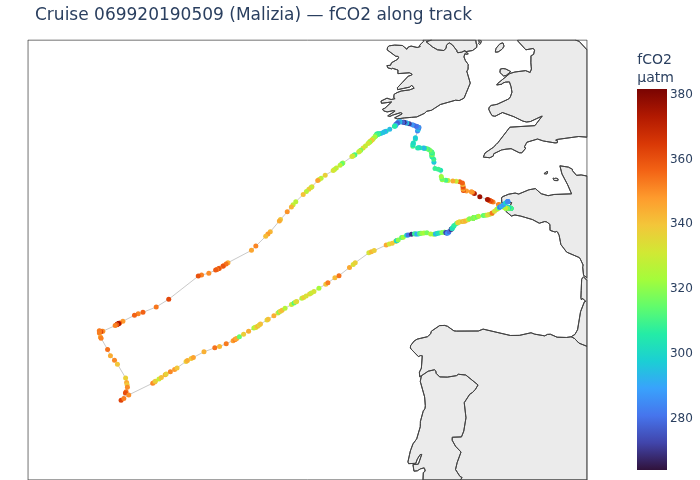

In [5]:
trk = track.dropna(subset=["fCO2"]).reset_index(drop=True)
keep = reduce_track(trk.longitude.values, trk.latitude.values, trk.fCO2.values)
tp = trk[keep]
print(f"track reduced {len(trk):,} → {len(tp):,} points ({100*len(tp)/len(trk):.1f}%)")

fig = go.Figure(go.Scattergeo(
    lon=tp.longitude, lat=tp.latitude, mode="lines+markers",
    line=dict(color="rgba(120,120,120,.4)", width=1),
    marker=dict(color=tp.fCO2, colorscale="Turbo", size=5,
                colorbar=dict(title="fCO2<br>µatm")),
    text=tp.time.dt.strftime("%Y-%m-%d %H:%M")))
fig.update_geos(projection_type="natural earth", resolution=50, showland=True,
                landcolor="rgb(235,235,235)", showcountries=True,
                lataxis_range=[float(one.southmost) - 3, float(one.northmost) + 3],
                lonaxis_range=[float(one.westmost) - 3, float(one.eastmost) + 3])
fig.update_layout(title=f"Cruise {one.cruise} ({one.platform_name}) — fCO2 along track",
                  height=480, margin=dict(l=0, r=0, t=40, b=0))
fig

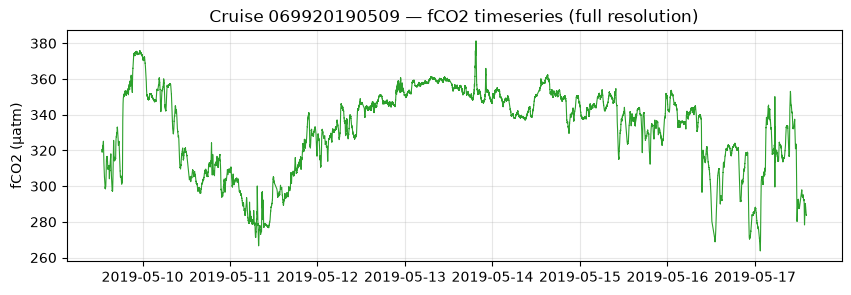

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(track.time, track.fCO2, lw=0.8, color="C2")
ax.set_ylabel("fCO2 (µatm)"); ax.grid(alpha=.3)
ax.set_title(f"Cruise {one.cruise} — fCO2 timeseries (full resolution)")
plt.show()

## 2. All cruises from one ship (platform)

Many cruises share a platform. Group by `platform_name`, concatenate each
cruise's contiguous slice, then reduce **per cruise** for the map.

In [7]:
g = cm.groupby("platform_name").agg(n_cruises=("cruise", "size"),
                                    n_obs=("obs_count", "sum"))
# a well-sampled ship with a manageable number of cruises
cand = g[(g.n_cruises >= 20) & (g.n_cruises <= 80)].sort_values("n_obs", ascending=False)
ship = cand.index[0]
ship_cruises = cm[cm.platform_name == ship]
print(f"ship: {ship!r}  ({len(ship_cruises)} cruises, "
      f"{int(ship_cruises.obs_count.sum()):,} obs)")

parts = []
for _, r in ship_cruises.iterrows():
    a, k = int(r.obs_start), int(r.obs_count)
    if k:
        parts.append(obs[["time", "latitude", "longitude", "fCO2"]]
                     .isel(obs=slice(a, a + k)).to_dataframe().assign(cruise=r.cruise))
ship_df = pd.concat(parts, ignore_index=True)
print("loaded", f"{len(ship_df):,}", "rows")
ship_df.head()

ship: 'Aurora Australis'  (59 cruises, 1,244,986 obs)


loaded 1,244,986 rows


,time,latitude,longitude,fCO2,cruise
0,1991-09-26 15:15:00,-46.056000,150.477997,343.531006,09AR19910926
1,1991-09-26 15:25:00,-46.083000,150.498001,345.309998,09AR19910926
2,1991-09-26 15:35:00,-46.109001,150.518005,344.539001,09AR19910926
3,1991-09-26 16:15:00,-46.217999,150.595993,342.992004,09AR19910926
4,1991-09-26 16:25:00,-46.248001,150.613007,345.858002,09AR19910926


reduced 1,244,986 → 15,000 points for plotting


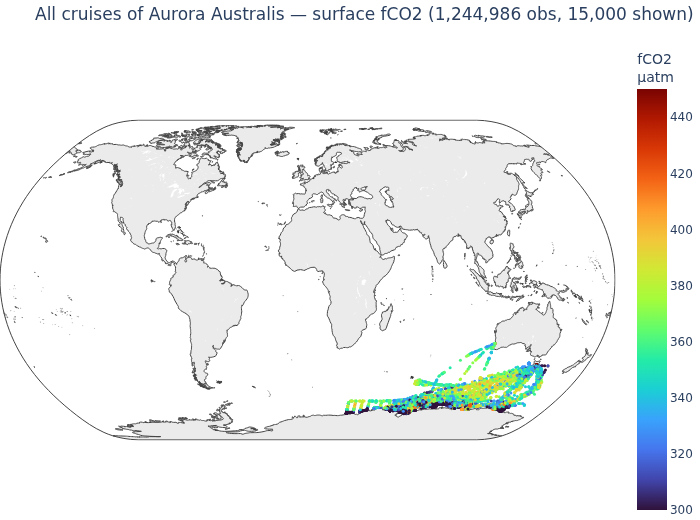

In [8]:
sp = reduce_by_cruise(ship_df, key="cruise")
print(f"reduced {len(ship_df):,} → {len(sp):,} points for plotting")
fig = go.Figure(go.Scattergeo(
    lon=sp.longitude, lat=sp.latitude, mode="markers",
    marker=dict(color=sp.fCO2, colorscale="Turbo", size=3, cmin=300, cmax=450,
                colorbar=dict(title="fCO2<br>µatm"))))
fig.update_geos(projection_type="natural earth", resolution=50, showland=True,
                landcolor="rgb(235,235,235)")
fig.update_layout(title=f"All cruises of {ship} — surface fCO2 "
                        f"({len(ship_df):,} obs, {len(sp):,} shown)", height=520,
                  margin=dict(l=0, r=0, t=40, b=0))
fig

## 3. Gridded fCO2 on a rotating globe

The gridded product is a `(time, lat, lon)` cube. Take a recent multi-year mean, and render it on an **orthographic globe** —
press ▶ spin.

27,870 cells (3° coarsened)


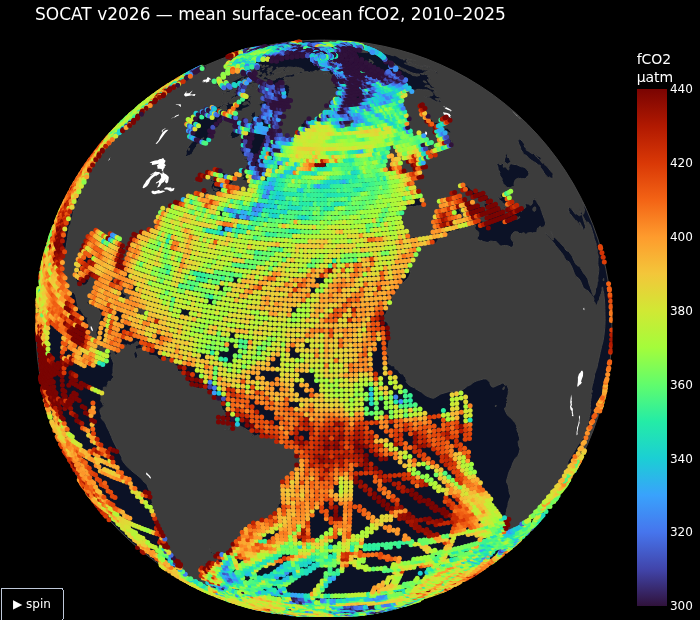

In [9]:
coarse = (grid.fco2_ave_weighted.sel(time=slice("2010", "2025")).mean("time")
          .coarsen(lat=1, lon=1, boundary="trim").mean())
gdf = coarse.to_dataframe(name="fco2").reset_index().dropna(subset=["fco2"])
print(f"{len(gdf):,} cells (3° coarsened)")

frames = [go.Frame(layout=dict(geo=dict(projection=dict(rotation=dict(lon=lng)))))
          for lng in range(0, 360, 20)]
fig = go.Figure(
    data=go.Scattergeo(
        lon=gdf.lon, lat=gdf.lat, mode="markers",
        marker=dict(color=gdf.fco2, colorscale="Turbo", size=5, cmin=300, cmax=440,
                    colorbar=dict(title="fCO2<br>µatm"))),
    frames=frames)
fig.update_geos(projection_type="orthographic", showland=True, showocean=True,
                landcolor="rgb(60,60,60)", oceancolor="rgb(12,18,38)", bgcolor="black",
                projection_rotation=dict(lon=-30, lat=20, roll=0))
fig.update_layout(
    height=620, paper_bgcolor="black", font_color="white",
    title="SOCAT v2026 — mean surface-ocean fCO2, 2010–2025",
    margin=dict(l=0, r=0, t=40, b=0),
    updatemenus=[dict(type="buttons", showactive=False, x=0.05, y=0.05,
        buttons=[dict(label="▶ spin", method="animate",
                      args=[None, dict(frame=dict(duration=120, redraw=True),
                                       fromcurrent=True, transition=dict(duration=0))])])])
fig

## 4. All North-Atlantic cruises in 2015–2020, on a map

First a focused **`/query` API** call (server-side filter → DataFrame + passport).
SOCAT has no per-platform citation text, but each cruise carries a *Data Source
DOI*; when a query touches **≤ 5** distinct source datasets the passport lists
them under `isBasedOn` (otherwise just the count, to stay compact). Then we load
the obs columns once, keep the North-Atlantic rows, and draw the 2015–2020
cruises reduced **per cruise**.

In [10]:
# A focused /query (one mid-Atlantic week) → its passport cites the individual
# source datasets it drew from.
df_demo, pp = query_df("socat._obs.fCO2", lat_min=42, lat_max=52, lon_min=-25, lon_max=2,
                       start="2019-05-09", end="2019-05-19", qc_max=2, max_rows=100000)
rec = pp["@graph"][1]
print(f"focused /query: {len(df_demo):,} obs, passport sha={rec['passportSha256'][:12]}…")
print("collection:", rec.get("citation", "")[:70], "| licence:", rec.get("license"))
print("source datasets cited:", rec.get("sourceDatasetCount"), "→", rec.get("isBasedOn"))

focused /query: 63,118 obs, passport sha=8f4e49f5407e…
collection: Bakker, Dorothee C. E., Alin, Simone R., Bates, Nicholas, Ehmen, Tobia | licence: CC-BY-4.0
source datasets cited: 3 → [{'@id': 'https://doi.org/10.25921/fvd0-z823'}, {'@id': 'https://doi.org/10.25921/kvq4-ea13'}, {'@id': 'https://doi.org/10.25921/y686-5a90'}]


In [11]:
# Load the obs columns once and keep North-Atlantic rows (the "download into a
# DataFrame" step). Re-used for both the map and the trend below.
lat = obs.latitude.values
lon = obs.longitude.values
box = (lat >= NA["lat_min"]) & (lat <= NA["lat_max"]) & \
      (lon >= NA["lon_min"]) & (lon <= NA["lon_max"])
na_all = pd.DataFrame({
    "time":       obs.time.values[box],
    "latitude":   lat[box],
    "longitude":  lon[box],
    "fCO2":       obs.fCO2.values[box],
    "qc":         obs.fCO2_QC.values[box],
    "cruise_idx": obs.cruise_idx.values[box],
})
na_all = na_all[na_all.qc == 2]
print(f"{len(na_all):,} North-Atlantic obs ({na_all.time.min():%Y} – {na_all.time.max():%Y})")

2,457,120 North-Atlantic obs (1981 – 2025)


2015–2020: 708,793 obs → 15,000 points after per-cruise reduction


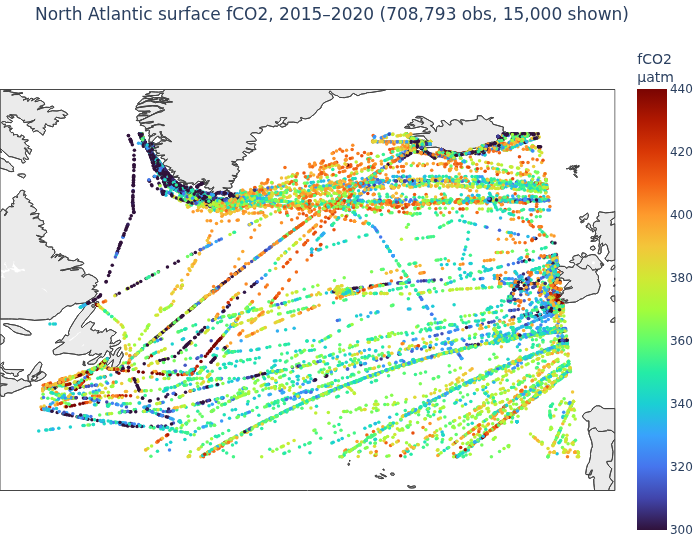

In [12]:
win = na_all[(na_all.time >= "2015-01-01") & (na_all.time < "2020-01-01")]
red = reduce_by_cruise(win, key="cruise_idx")
print(f"2015–2020: {len(win):,} obs → {len(red):,} points after per-cruise reduction")

fig = go.Figure(go.Scattergeo(
    lon=red.longitude, lat=red.latitude, mode="markers",
    marker=dict(color=red.fCO2, colorscale="Turbo", size=3.5, cmin=300, cmax=440,
                colorbar=dict(title="fCO2<br>µatm"))))
fig.update_geos(projection_type="natural earth", resolution=50, showland=True,
                landcolor="rgb(235,235,235)", showcountries=True,
                lataxis_range=[NA["lat_min"] - 3, NA["lat_max"] + 3],
                lonaxis_range=[NA["lon_min"] - 3, NA["lon_max"] + 3])
fig.update_layout(title=f"North Atlantic surface fCO2, 2015–2020 "
                        f"({len(win):,} obs, {len(red):,} shown)", height=540,
                  margin=dict(l=0, r=0, t=40, b=0))
fig

## 5. Regional fCO2 trend, 2000–2025 — gridded vs. cruises

- **Gridded:** spatial mean of each monthly map over the box.
- **Cruises:** average the North-Atlantic obs by year.

Both should track the atmospheric-CO2-driven rise (≈ 1.5–2 µatm yr⁻¹).

In [13]:
# gridded: monthly spatial mean over the box
gbox = grid.fco2_ave_weighted.sel(lat=slice(NA["lat_min"], NA["lat_max"]),
                                  lon=slice(NA["lon_min"], NA["lon_max"]),
                                  time=slice("2000", "2025"))
g_monthly = gbox.mean(["lat", "lon"]).to_series().dropna()
g_annual = g_monthly.groupby(g_monthly.index.year).mean()

# cruises: annual mean from the obs already loaded above
c = na_all[(na_all.time >= "2000-01-01") & (na_all.time < "2026-01-01")].copy()
c["year"] = c.time.dt.year
c_annual = c.groupby("year").fCO2.mean()
print(f"gridded months: {len(g_monthly)}   cruise obs: {len(c):,}")

gridded months: 286   cruise obs: 2,222,880


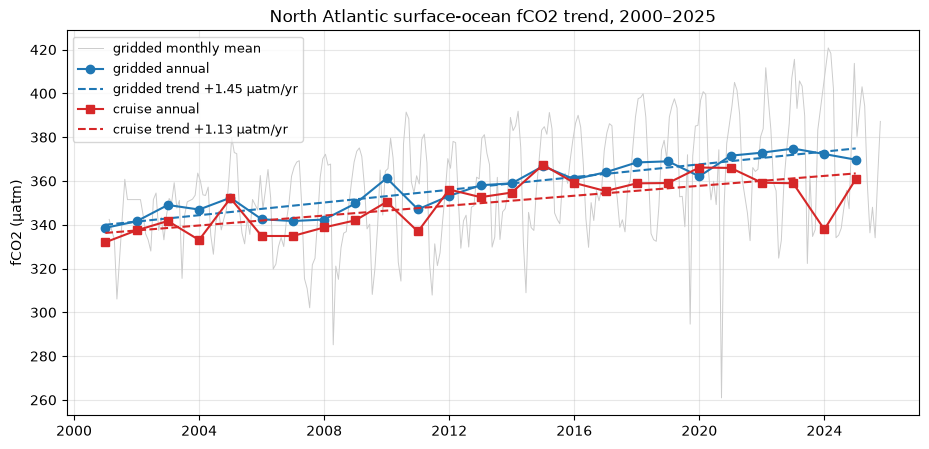

gridded trend: +1.45 µatm/yr     cruise trend: +1.13 µatm/yr


In [14]:
def linfit(years, vals):
    x = np.asarray(years, float); y = np.asarray(vals, float)
    slope, intercept = np.polyfit(x, y, 1)
    return slope, slope * x + intercept

gx, cx = g_annual.index.values, c_annual.index.values
g_slope, g_line = linfit(gx, g_annual.values)
c_slope, c_line = linfit(cx, c_annual.values)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(g_monthly.index, g_monthly.values, color="0.8", lw=0.7, label="gridded monthly mean")
ax.plot(pd.to_datetime(gx, format="%Y"), g_annual.values, "o-", color="C0", label="gridded annual")
ax.plot(pd.to_datetime(gx, format="%Y"), g_line, "--", color="C0",
        label=f"gridded trend {g_slope:+.2f} µatm/yr")
ax.plot(pd.to_datetime(cx, format="%Y"), c_annual.values, "s-", color="C3", label="cruise annual")
ax.plot(pd.to_datetime(cx, format="%Y"), c_line, "--", color="C3",
        label=f"cruise trend {c_slope:+.2f} µatm/yr")
ax.set_title("North Atlantic surface-ocean fCO2 trend, 2000–2025")
ax.set_ylabel("fCO2 (µatm)"); ax.grid(alpha=.3); ax.legend(loc="upper left", fontsize=9)
plt.show()

print(f"gridded trend: {g_slope:+.2f} µatm/yr     cruise trend: {c_slope:+.2f} µatm/yr")

### The data passport

Every `/query` download is self-documenting: the trailing NDJSON line is a
RO-Crate passport recording the variable, store, bbox, time window, QC filter,
row count and a SHA-256 — plus the **licence** (CC-BY-4.0), the **collection
citation** (SOCAT v2026 DOI), and, when ≤ 5 distinct datasets were touched, the
**per-dataset source DOIs** under `isBasedOn`. Provenance you can keep with the figure.

In [15]:
print(json.dumps(pp["@graph"][1], indent=2)[:2000])

{
  "@id": "urn:uuid:62e4526d-315e-42eb-8930-346c29ac87d0",
  "@type": [
    "Dataset",
    "icos:DataPassport"
  ],
  "name": "Data query passport \u2014 fCO2 (2026-08-17)",
  "url": "",
  "dateAccessed": "2026-08-17T17:16:46Z",
  "sessionStart": "2026-08-17T17:16:46Z",
  "sessionEnd": "2026-08-17T17:16:57Z",
  "agent": {
    "@type": "Agent",
    "ipAnonymised": "130.235.92.0/24"
  },
  "accessedGroups": [
    "_obs"
  ],
  "accessedArrays": [
    "fCO2"
  ],
  "stations": [],
  "query": [
    {
      "variable": "fCO2",
      "store": "socat.zarr",
      "group": "_obs",
      "query_kind": "obs_table",
      "bbox": {
        "lat_min": 42.0,
        "lat_max": 52.0,
        "lon_min": -25.0,
        "lon_max": 2.0
      },
      "time": {
        "start": "2019-05-09",
        "end": "2019-05-19"
      },
      "qc_max": 2
    }
  ],
  "hasPart": [
    {
      "@id": "_obs/fCO2"
    }
  ],
  "totalBytesServed": 9251340,
  "totalRows": 63118,
  "truncated": false,
  "passportSha256